# Credit Risk Exposures

## Basic Toy Model (with Interest Rate Swaps)

In [26]:
import numpy as np

def rate_models(r0, kappa, theta, sigma, T, dt, num_simulations, model_type, seed = 1000):

    rng = np.random.default_rng(seed=seed)
    n_steps = int(T/dt)
    rates = np.zeros((num_simulations, n_steps))
    rates[:,0] = r0

    if model_type == 'Vasicek':
        for t in range(1, n_steps):
            dW = rng.standard_normal(size=num_simulations)
            rates[:, t] = rates[:, t-1] + kappa * (theta - rates[:, t-1]) * dt + sigma * np.sqrt(dt) * dW
    
    elif model_type == 'Hull-White':
        exp_kdt = np.exp(-kappa * dt)
        sigma_terms = sigma * np.sqrt((1 - np.exp(-2 * kappa * dt))/(2 * kappa))
        for t in range(1, n_steps):
            z = rng.standard_normal(size=num_simulations)
            rates[:,t] = rates[:, t-1] * exp_kdt + theta * (1 - exp_kdt) + sigma_terms * z
    else:
        print(f"Please insert correct model type as 'Vasicek' or 'Hull-White'....")
    
    return rates

def swap_exposures(rates, fixed_rate= 0.02, notional = 1_000_000):
    mtm = (rates - fixed_rate) * notional
    return mtm

def ccr_metrics(exp, q=0.99):
    ee = np.mean(exp, axis=0)
    epe = np.mean(np.maximum(exp, 0), axis=0)
    pfe = np.quantile(np.maximum(exp, 0), q, axis=0)
    return ee, epe, pfe


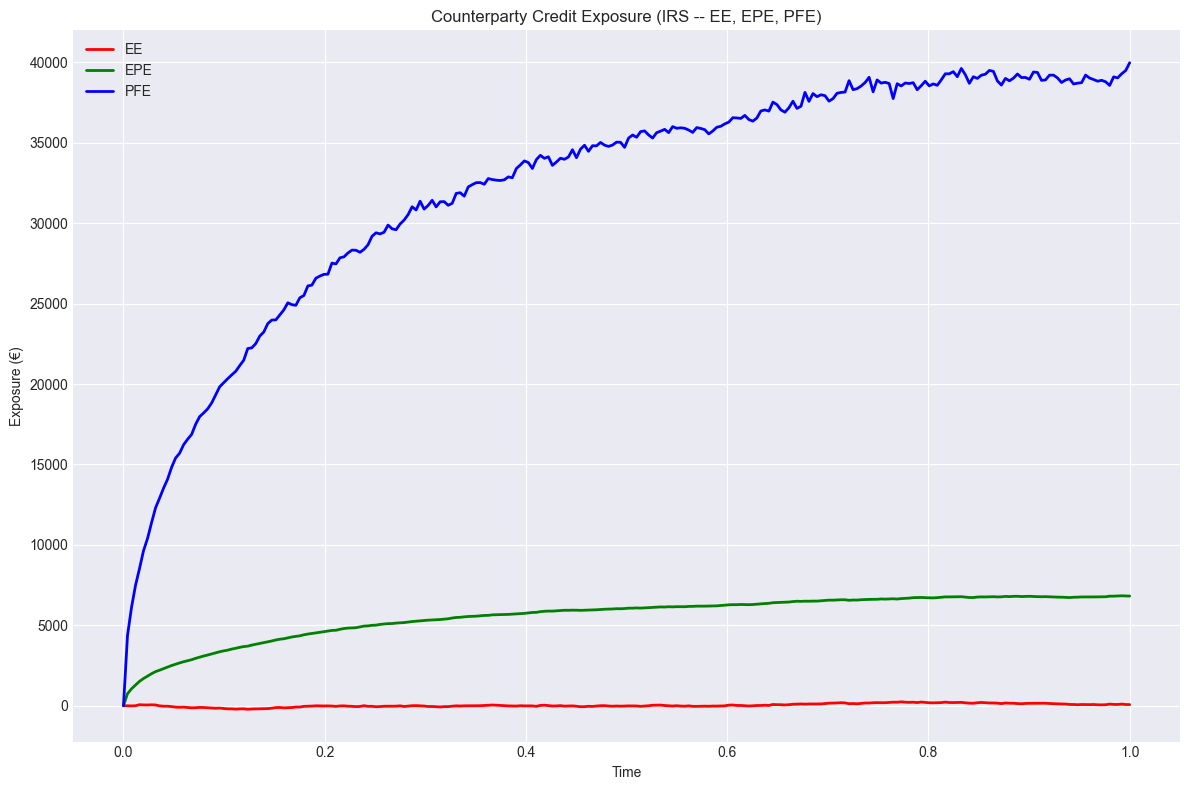

In [27]:
import numpy as np
import matplotlib.pyplot as plt

r0 = 0.02
kappa = 1.5
theta = .02
sigma = 0.03
T = 1
dt = 1/252
num_simulations = 10_000

# Calculations
rates = rate_models(
    r0=r0, 
    kappa=kappa, 
    theta=theta, 
    sigma=sigma, 
    T=T, 
    dt=dt, 
    num_simulations=num_simulations, 
    model_type='Hull-White',
    seed=10000
    )

exposure_paths = swap_exposures(rates=rates)
ee, epe, pfe = ccr_metrics(exp=exposure_paths)

# Plotting the results
time_grid = np.linspace(0, T, exposure_paths.shape[1])
plt.plot(time_grid, ee, color = 'r', label = 'EE')
plt.plot(time_grid, epe, color = 'g', label = 'EPE')
plt.plot(time_grid, pfe, color = 'b', label = 'PFE')
plt.legend(frameon = False)
plt.title('Counterparty Credit Exposure (IRS -- EE, EPE, PFE)')
plt.xlabel('Time')
plt.ylabel('Exposure (€)')
plt.tight_layout()
plt.show()


## Multiple Asset Portfolio

* Steps to Add
    - Risk Factor simulation
        - Interest rates (HW/LMM/Vasicek)
        - FX (GBM)
        - Equity (GBM/Heston)
        - Credit Spread (Hazard rate)
    - Portfolio Valuation
        - Reprice trades under each scenarios
    - Exposure engine
        - Exposure = max(mtm, 0)
    - Aggregation & Risk Metrics
        - EE, EPE, PFE
        - CVA, DVA, FVA

In [28]:
# Multi-Asset Modeling
import numpy as np

# step 1
def generate_correlated_normals(num_simulations, cor_matrix, seed=1000):
    rng = np.random.default_rng(seed=seed)
    L = np.linalg.cholesky(cor_matrix)
    z = rng.normal(size=(num_simulations, cor_matrix.shape[0]))
    return z@L.T

# Step 2
def simulate_markets(r0, s0_fx, s0_eq, kappa, theta, sigma_r, sigma_fx, sigma_eq, cor_matrix, T, dt, num_simulations, seed = 11000):
    rng = np.random.default_rng(seed=seed)
    n_steps = int(T/dt) + 1

    rates = np.zeros((num_simulations, n_steps))
    fx = np.zeros((num_simulations, n_steps))
    equity = np.zeros((num_simulations, n_steps))

    rates[:, 0] = r0
    fx[:, 0] = s0_fx
    equity[:, 0] = s0_eq

    # Hull-White
    exp_kdt = np.exp(-kappa * dt)
    vol_r = sigma_r * np.sqrt((1-np.exp(-2*kappa*dt))/(2*kappa))

    for t in range(1, n_steps):
        shocks = generate_correlated_normals(num_simulations=num_simulations, cor_matrix=cor_matrix, seed=seed)

        z_r = shocks[:, 0]
        z_fx = shocks[:, 1]
        z_eq = shocks[:, 2]

        rates[:, t] = (rates[:,t-1] * exp_kdt + theta * (1 - exp_kdt) + vol_r * z_r)
        fx[:, t] = fx[:,t-1] * np.exp(-0.5 * sigma_fx**2 * dt + sigma_fx * np.sqrt(dt) * z_fx)
        equity[:, t] = equity[:, t-1] * np.exp(-0.5 * sigma_eq**2 * dt + sigma_eq * np.sqrt(dt) * z_eq)

        return rates, fx, equity

# Step 3
def portfolio_valuation(rates, fx, equity, swap_rate = 0.02, fx_strike = 1.00, eq_strike = 100, notional = 10_000):
    swap = notional * (rates - swap_rate) # irs swaps
    fx_trade = notional * (fx - fx_strike) # fx forward
    eq_trade = notional * np.maximum(equity - eq_strike, 0) # call equity

    portfolio_value = swap + fx_trade + eq_trade

    return portfolio_value

# Step 4
def ccr_metrics(exp, q=0.99):
    ee = np.mean(exp, axis=0)
    epe = np.mean(np.maximum(exp,0), axis=0)
    pfe = np.quantile(np.maximum(exp,0), q, axis=0)
    return ee, epe, pfe

def calculate_cva()



SyntaxError: expected ':' (3080736119.py, line 58)

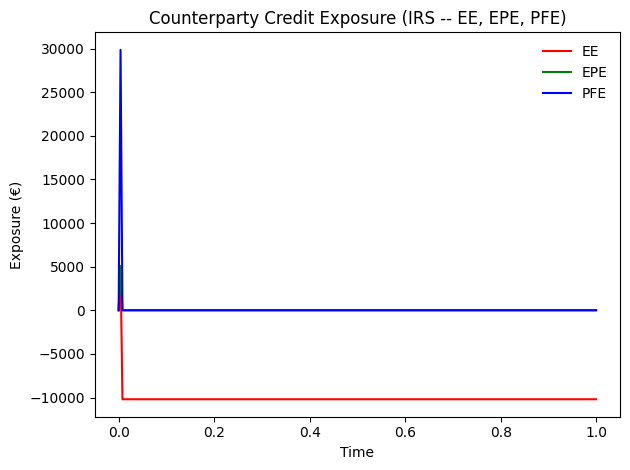

In [ ]:
import matplotlib.pyplot as plt

r0 = 0.02
s0_fx = 1.0
s0_eq = 100

kappa = 1.56
theta = 0.20

sigma_r = 0.0145
sigma_fx = 0.12
sigma_eq = 0.20

cor_matrix = np.array([
    [1.0, -0.30, 0.20],
    [-0.30, 1.0, 0.40],
    [0.20, 0.40, 1.0],
])

T = 1
dt = 1 / 252
num_simulations = 50_000

rates, fx, equity = simulate_markets(r0=r0, s0_fx=s0_fx, s0_eq=s0_eq, kappa=kappa, theta=theta, sigma_r=sigma_r, sigma_fx=sigma_fx, sigma_eq=sigma_eq, cor_matrix=cor_matrix, T=T, dt=dt, num_simulations=num_simulations)
exposure_paths = portfolio_valuation(rates=rates, fx=fx, equity=equity)
ee, epe, pfe = ccr_metrics(exp=exposure_paths)

time_grid = np.linspace(0, T, exposure_paths.shape[1])
plt.plot(time_grid, ee, color = 'r', label = 'EE')
plt.plot(time_grid, epe, color = 'g', label = 'EPE')
plt.plot(time_grid, pfe, color = 'b', label = 'PFE')
plt.legend(frameon = False)
plt.title('Counterparty Credit Exposure (IRS -- EE, EPE, PFE)')
plt.xlabel('Time')
plt.ylabel('Exposure (€)')
plt.tight_layout()
plt.show()

In [ ]:
"""
Multi-Asset Modeling with CVA
Complete functional implementation
"""

import numpy as np
from typing import Tuple, Optional

# Step 1: Generate correlated normals
def generate_correlated_normals(num_simulations, cor_matrix, seed=1000):
    """
    Generate correlated normal random variables using Cholesky decomposition.
    """
    rng = np.random.default_rng(seed=seed)
    L = np.linalg.cholesky(cor_matrix)
    z = rng.normal(size=(num_simulations, cor_matrix.shape[0]))
    return z @ L.T


# Step 2: Simulate markets
def simulate_markets(r0, s0_fx, s0_eq, kappa, theta, sigma_r, sigma_fx, sigma_eq, 
                     cor_matrix, T, dt, num_simulations, seed=11000):
    """
    Simulate correlated markets: rates (Hull-White), FX (GBM), Equity (GBM).
    """
    n_steps = int(T/dt) + 1

    rates = np.zeros((num_simulations, n_steps))
    fx = np.zeros((num_simulations, n_steps))
    equity = np.zeros((num_simulations, n_steps))

    rates[:, 0] = r0
    fx[:, 0] = s0_fx
    equity[:, 0] = s0_eq

    # Hull-White parameters
    exp_kdt = np.exp(-kappa * dt)
    vol_r = sigma_r * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa))

    for t in range(1, n_steps):
        shocks = generate_correlated_normals(num_simulations=num_simulations, 
                                            cor_matrix=cor_matrix, 
                                            seed=seed + t)  # Different seed for each step

        z_r = shocks[:, 0]
        z_fx = shocks[:, 1]
        z_eq = shocks[:, 2]

        rates[:, t] = (rates[:, t-1] * exp_kdt + theta * (1 - exp_kdt) + vol_r * z_r)
        fx[:, t] = fx[:, t-1] * np.exp(-0.5 * sigma_fx**2 * dt + sigma_fx * np.sqrt(dt) * z_fx)
        equity[:, t] = equity[:, t-1] * np.exp(-0.5 * sigma_eq**2 * dt + sigma_eq * np.sqrt(dt) * z_eq)

    return rates, fx, equity


# Step 3: Portfolio valuation
def portfolio_valuation(rates, fx, equity, swap_rate=0.02, fx_strike=1.00, 
                        eq_strike=100, notional=10_000):
    """
    Value the portfolio consisting of IRS swap, FX forward, and equity call option.
    """
    swap = notional * (rates - swap_rate)  # Interest rate swap
    fx_trade = notional * (fx - fx_strike)  # FX forward
    eq_trade = notional * np.maximum(equity - eq_strike, 0)  # Equity call

    portfolio_value = swap + fx_trade + eq_trade
    return portfolio_value


# Step 4: CCR metrics
def ccr_metrics(exp, q=0.99):
    """
    Calculate CCR metrics: EE, EPE, PFE.
    """
    ee = np.mean(exp, axis=0)
    epe = np.mean(np.maximum(exp, 0), axis=0)
    pfe = np.quantile(np.maximum(exp, 0), q, axis=0)
    return ee, epe, pfe


# Step 5: CVA Calculation (NEW)
def calculate_cva(portfolio_values, rates, time_grid, hazard_rate, recovery_rate=0.4, dt=None):
    """
    Calculate Credit Valuation Adjustment (CVA).
    
    Args:
        portfolio_values: Portfolio values (num_simulations, n_steps)
        rates: Simulated interest rates (num_simulations, n_steps)
        time_grid: Time points (n_steps,)
        hazard_rate: Annual probability of default
        recovery_rate: Recovery rate (0-1)
        dt: Time step (if None, calculated from time_grid)
    
    Returns:
        CVA amount and additional metrics
    """
    # Calculate Loss Given Default
    lgd = 1 - recovery_rate
    
    # Step 1: Calculate Expected Exposure (EE)
    # EE is the average positive exposure across all paths
    ee = np.mean(np.maximum(portfolio_values, 0), axis=0)
    
    # Step 2: Calculate Probability of Default (PD)
    # Survival probability up to time t
    survival_prob = np.exp(-hazard_rate * time_grid)
    
    # Probability of default between t_{i-1} and t_i
    default_prob = np.zeros_like(survival_prob)
    default_prob[0] = 1 - survival_prob[0]  # Default in first period
    for i in range(1, len(survival_prob)):
        default_prob[i] = survival_prob[i-1] - survival_prob[i]
    
    # Step 3: Calculate Discount Factors from simulated rates
    # Method: Pathwise discounting (more accurate)
    n_sim, n_steps = rates.shape
    
    # Calculate discount factors for each path
    pathwise_df = np.zeros_like(rates)
    pathwise_df[:, 0] = 1.0  # DF(0) = 1
    
    for t in range(1, n_steps):
        # Time increment
        if dt is not None:
            dt_t = dt
        else:
            dt_t = time_grid[t] - time_grid[t-1]
        
        # Continuous compounding: DF(t) = DF(t-1) * exp(-r(t) * dt)
        pathwise_df[:, t] = pathwise_df[:, t-1] * np.exp(-rates[:, t] * dt_t)
    
    # Average discount factors across all paths
    avg_discount_factors = np.mean(pathwise_df, axis=0)
    
    # Step 4: Calculate CVA
    # CVA = LGD * sum(EE(t) * PD(t) * DF(t))
    cva = lgd * np.sum(ee * default_prob * avg_discount_factors)
    
    # Step 5: Additional metrics for analysis
    # Contributions by time period
    period_contributions = lgd * ee * default_prob * avg_discount_factors
    
    # Maximum exposure contribution
    max_contribution_idx = np.argmax(period_contributions)
    max_contribution_time = time_grid[max_contribution_idx]
    
    # Return comprehensive results
    return {
        'cva': cva,
        'expected_exposure': ee,
        'default_probabilities': default_prob,
        'discount_factors': avg_discount_factors,
        'period_contributions': period_contributions,
        'max_contribution_time': max_contribution_time,
        'lgd': lgd,
        'hazard_rate': hazard_rate
    }


# Step 6: Complete workflow with CVA integration
def run_complete_ccr_model(
    # Market parameters
    r0=0.02, s0_fx=1.10, s0_eq=100.0,
    kappa=0.1, theta=0.03, sigma_r=0.01,
    sigma_fx=0.15, sigma_eq=0.25,
    cor_matrix=None,
    
    # Simulation parameters
    T=5.0, dt=0.25, num_simulations=10000, seed=42,
    
    # Trade parameters
    swap_rate=0.025, fx_strike=1.12, eq_strike=105.0,
    notional=1_000_000,
    
    # CVA parameters
    hazard_rate=0.02, recovery_rate=0.4,
    
    # Output options
    verbose=True
):
    """
    Run complete CCR model including simulation, valuation, metrics, and CVA.
    """
    
    # Set default correlation matrix if not provided
    if cor_matrix is None:
        cor_matrix = np.array([
            [1.0, 0.3, 0.2],
            [0.3, 1.0, 0.4],
            [0.2, 0.4, 1.0]
        ])
    
    if verbose:
        print("=" * 70)
        print("RUNNING COMPLETE CCR MODEL WITH CVA")
        print("=" * 70)
        print(f"Simulations: {num_simulations:,}")
        print(f"Time horizon: {T} years")
        print(f"Time steps: {int(T/dt)}")
        print(f"Notional: ${notional:,.0f}")
        print(f"Hazard rate: {hazard_rate:.2%}")
        print(f"Recovery rate: {recovery_rate:.2%}")
        print("-" * 70)
    
    # Step 1: Simulate markets
    if verbose:
        print("Step 1: Simulating markets...")
    
    rates, fx, equity = simulate_markets(
        r0=r0, s0_fx=s0_fx, s0_eq=s0_eq,
        kappa=kappa, theta=theta,
        sigma_r=sigma_r, sigma_fx=sigma_fx, sigma_eq=sigma_eq,
        cor_matrix=cor_matrix,
        T=T, dt=dt,
        num_simulations=num_simulations,
        seed=seed
    )
    
    if verbose:
        print(f"  Rates shape: {rates.shape}")
        print(f"  FX shape: {fx.shape}")
        print(f"  Equity shape: {equity.shape}")
    
    # Step 2: Value portfolio
    if verbose:
        print("Step 2: Valuing portfolio...")
    
    portfolio_values = portfolio_valuation(
        rates=rates, fx=fx, equity=equity,
        swap_rate=swap_rate, fx_strike=fx_strike,
        eq_strike=eq_strike, notional=notional
    )
    
    if verbose:
        print(f"  Portfolio value range: [{np.min(portfolio_values):.2f}, {np.max(portfolio_values):.2f}]")
        print(f"  Mean portfolio value: {np.mean(portfolio_values):.2f}")
    
    # Step 3: Calculate CCR metrics
    if verbose:
        print("Step 3: Calculating CCR metrics...")
    
    ee, epe, pfe = ccr_metrics(portfolio_values, q=0.99)
    
    if verbose:
        print(f"  Max EE: {np.max(ee):.2f}")
        print(f"  Max EPE: {np.max(epe):.2f}")
        print(f"  Max PFE (99%): {np.max(pfe):.2f}")
        print(f"  Final EE: {ee[-1]:.2f}")
    
    # Step 4: Calculate CVA
    if verbose:
        print("Step 4: Calculating CVA...")
    
    n_steps = int(T/dt) + 1
    time_grid = np.linspace(0, T, n_steps)
    
    cva_results = calculate_cva(
        portfolio_values=portfolio_values,
        rates=rates,
        time_grid=time_grid,
        hazard_rate=hazard_rate,
        recovery_rate=recovery_rate,
        dt=dt
    )
    
    if verbose:
        print(f"  CVA: ${cva_results['cva']:,.2f}")
        print(f"  Max contribution at t={cva_results['max_contribution_time']:.2f} years")
        print(f"  LGD: {cva_results['lgd']:.2%}")
        print("-" * 70)
        print("SUMMARY RESULTS:")
        print(f"  Expected Exposure (final): ${ee[-1]:,.2f}")
        print(f"  Expected Positive Exposure (final): ${epe[-1]:,.2f}")
        print(f"  Potential Future Exposure (99%): ${pfe[-1]:,.2f}")
        print(f"  CVA: ${cva_results['cva']:,.2f}")
        print("=" * 70)
    
    # Return all results
    return {
        'rates': rates,
        'fx': fx,
        'equity': equity,
        'portfolio_values': portfolio_values,
        'ee': ee,
        'epe': epe,
        'pfe': pfe,
        'cva_results': cva_results,
        'time_grid': time_grid,
        'parameters': {
            'r0': r0, 's0_fx': s0_fx, 's0_eq': s0_eq,
            'kappa': kappa, 'theta': theta,
            'sigma_r': sigma_r, 'sigma_fx': sigma_fx, 'sigma_eq': sigma_eq,
            'T': T, 'dt': dt,
            'num_simulations': num_simulations,
            'swap_rate': swap_rate,
            'fx_strike': fx_strike,
            'eq_strike': eq_strike,
            'notional': notional,
            'hazard_rate': hazard_rate,
            'recovery_rate': recovery_rate
        }
    }


# =============================================================================
# Example Usage
# =============================================================================

if __name__ == "__main__":
    # Example 1: Run with default parameters
    print("\n" + "=" * 70)
    print("EXAMPLE 1: STANDARD RUN WITH CVA")
    print("=" * 70)
    
    results = run_complete_ccr_model(
        num_simulations=5000,  # Reduced for speed
        T=5.0,
        dt=0.25,
        verbose=True
    )
    
    # Example 2: Sensitivity analysis - varying hazard rate
    print("\n" + "=" * 70)
    print("EXAMPLE 2: CVA SENSITIVITY TO HAZARD RATE")
    print("=" * 70)
    
    hazard_rates = [0.01, 0.02, 0.03, 0.05, 0.10]
    cva_values = []
    
    for hr in hazard_rates:
        results = run_complete_ccr_model(
            num_simulations=2000,  # Reduced for speed
            T=3.0,
            dt=0.25,
            hazard_rate=hr,
            verbose=False  # Turn off verbose output
        )
        cva_values.append(results['cva_results']['cva'])
        print(f"Hazard rate: {hr:.2%} -> CVA: ${results['cva_results']['cva']:,.2f}")
    
    # Example 3: Manual step-by-step (if you want more control)
    print("\n" + "=" * 70)
    print("EXAMPLE 3: MANUAL STEP-BY-STEP EXECUTION")
    print("=" * 70)
    
    # Parameters
    r0, s0_fx, s0_eq = 0.02, 1.10, 100.0
    kappa, theta, sigma_r = 0.1, 0.03, 0.01
    sigma_fx, sigma_eq = 0.15, 0.25
    cor_matrix = np.array([[1.0, 0.3, 0.2], [0.3, 1.0, 0.4], [0.2, 0.4, 1.0]])
    T, dt = 5.0, 0.25
    num_simulations = 3000
    
    # Step 1: Simulate
    print("Step 1: Simulating markets...")
    rates, fx, equity = simulate_markets(
        r0, s0_fx, s0_eq, kappa, theta, sigma_r, sigma_fx, sigma_eq,
        cor_matrix, T, dt, num_simulations, seed=123
    )
    
    # Step 2: Value portfolio
    print("Step 2: Valuing portfolio...")
    portfolio_values = portfolio_valuation(rates, fx, equity)
    
    # Step 3: Calculate CCR metrics
    print("Step 3: Calculating CCR metrics...")
    ee, epe, pfe = ccr_metrics(portfolio_values)
    print(f"  Max EE: {np.max(ee):.2f}")
    print(f"  Max PFE: {np.max(pfe):.2f}")
    
    # Step 4: Calculate CVA
    print("Step 4: Calculating CVA...")
    n_steps = int(T/dt) + 1
    time_grid = np.linspace(0, T, n_steps)
    cva_results = calculate_cva(
        portfolio_values, rates, time_grid,
        hazard_rate=0.02, recovery_rate=0.4, dt=dt
    )
    print(f"  CVA: ${cva_results['cva']:,.2f}")
    
    print("\n" + "=" * 70)
    print("All examples completed successfully!")
    print("=" * 70)


EXAMPLE 1: STANDARD RUN WITH CVA
RUNNING COMPLETE CCR MODEL WITH CVA
Simulations: 5,000
Time horizon: 5.0 years
Time steps: 20
Notional: $1,000,000
Hazard rate: 2.00%
Recovery rate: 40.00%
----------------------------------------------------------------------
Step 1: Simulating markets...
  Rates shape: (5000, 21)
  FX shape: (5000, 21)
  Equity shape: (5000, 21)
Step 2: Valuing portfolio...
  Portfolio value range: [-876936.08, 619337951.40]
  Mean portfolio value: 12307996.60
Step 3: Calculating CCR metrics...
  Max EE: 19693765.19
  Max EPE: 19820445.09
  Max PFE (99%): 218579064.33
  Final EE: 19693765.19
Step 4: Calculating CVA...
  CVA: $687,712.12
  Max contribution at t=5.00 years
  LGD: 60.00%
----------------------------------------------------------------------
SUMMARY RESULTS:
  Expected Exposure (final): $19,693,765.19
  Expected Positive Exposure (final): $19,820,445.09
  Potential Future Exposure (99%): $218,579,064.33
  CVA: $687,712.12

EXAMPLE 2: CVA SENSITIVITY TO H


EXAMPLE 1: STANDARD RUN WITH CVA AND PLOTS
RUNNING COMPLETE CCR MODEL WITH CVA
Simulations: 3,000
Time horizon: 5.0 years
Time steps: 20
Notional: $1,000,000
Hazard rate: 2.00%
Recovery rate: 40.00%
----------------------------------------------------------------------
Step 1: Simulating markets...
  Rates shape: (3000, 21)
  FX shape: (3000, 21)
  Equity shape: (3000, 21)
Step 2: Valuing portfolio...
  Portfolio value range: [-876936.08, 466732707.08]
  Mean portfolio value: 12607525.63
Step 3: Calculating CCR metrics...
  Max EE: 20517689.58
  Max EPE: 20643078.55
  Max PFE (99%): 235966795.90
  Final EE: 20517689.58
Step 4: Calculating CVA...
  CVA: $703,760.09
  Max contribution at t=5.00 years
  LGD: 60.00%
----------------------------------------------------------------------
SUMMARY RESULTS:
  Expected Exposure (final): $20,517,689.58
  Expected Positive Exposure (final): $20,643,078.55
  Potential Future Exposure (99%): $235,966,795.90
  CVA: $703,760.09

Generating plots...


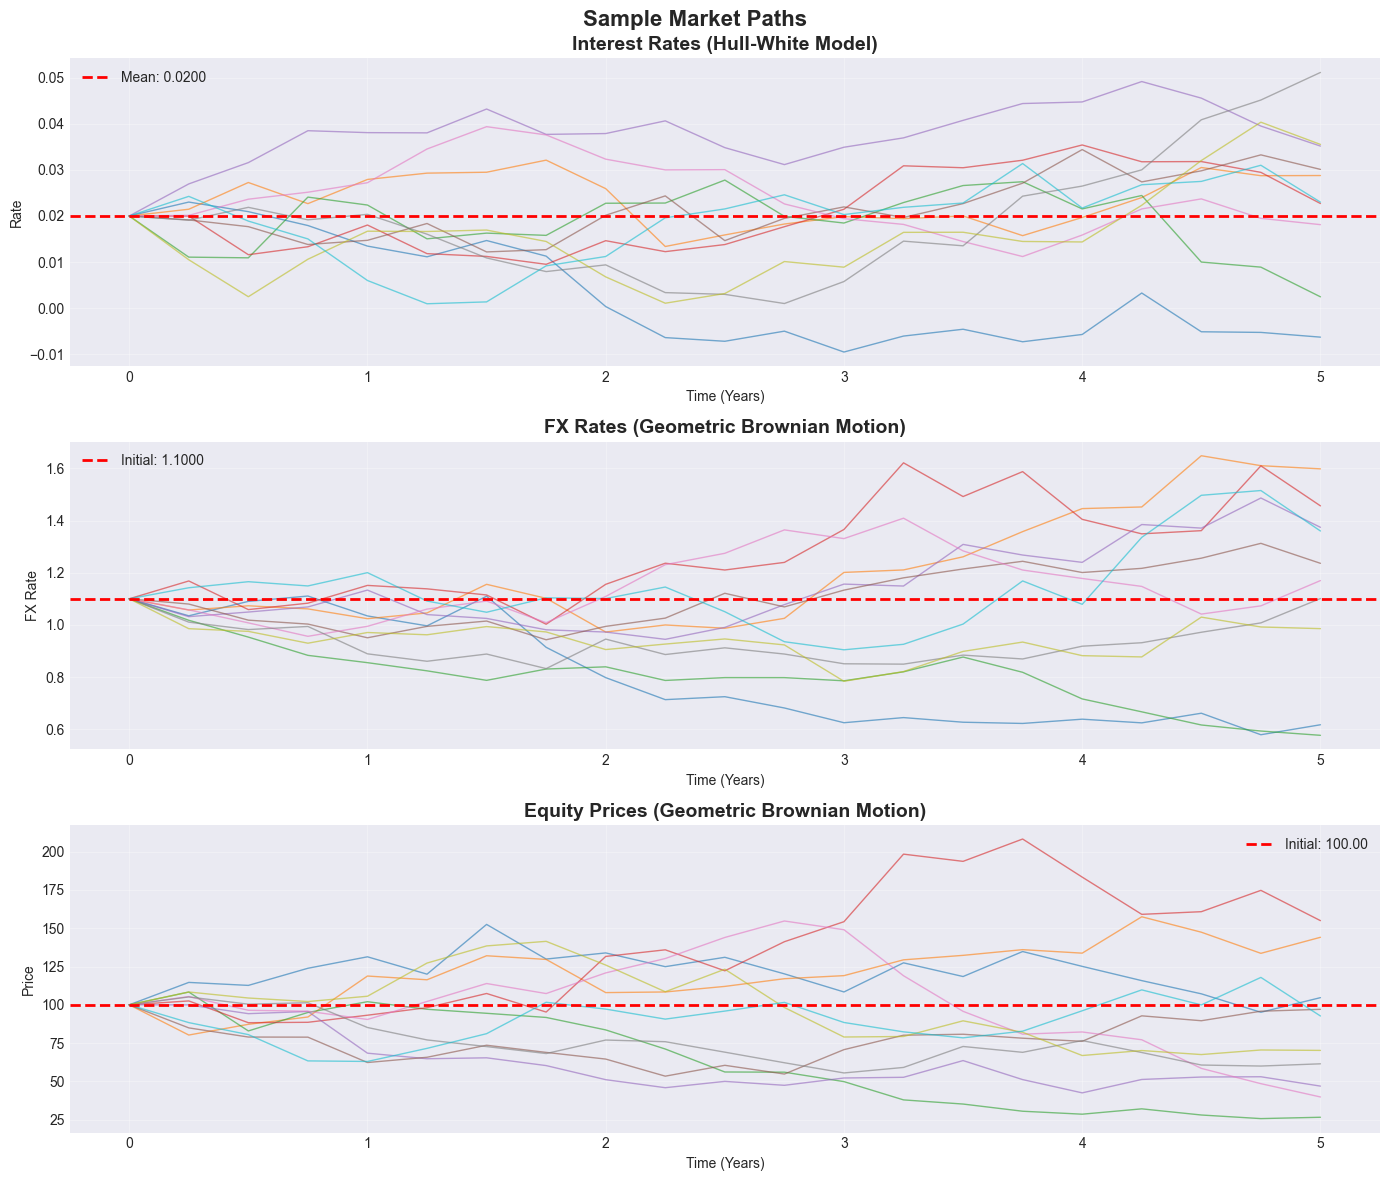

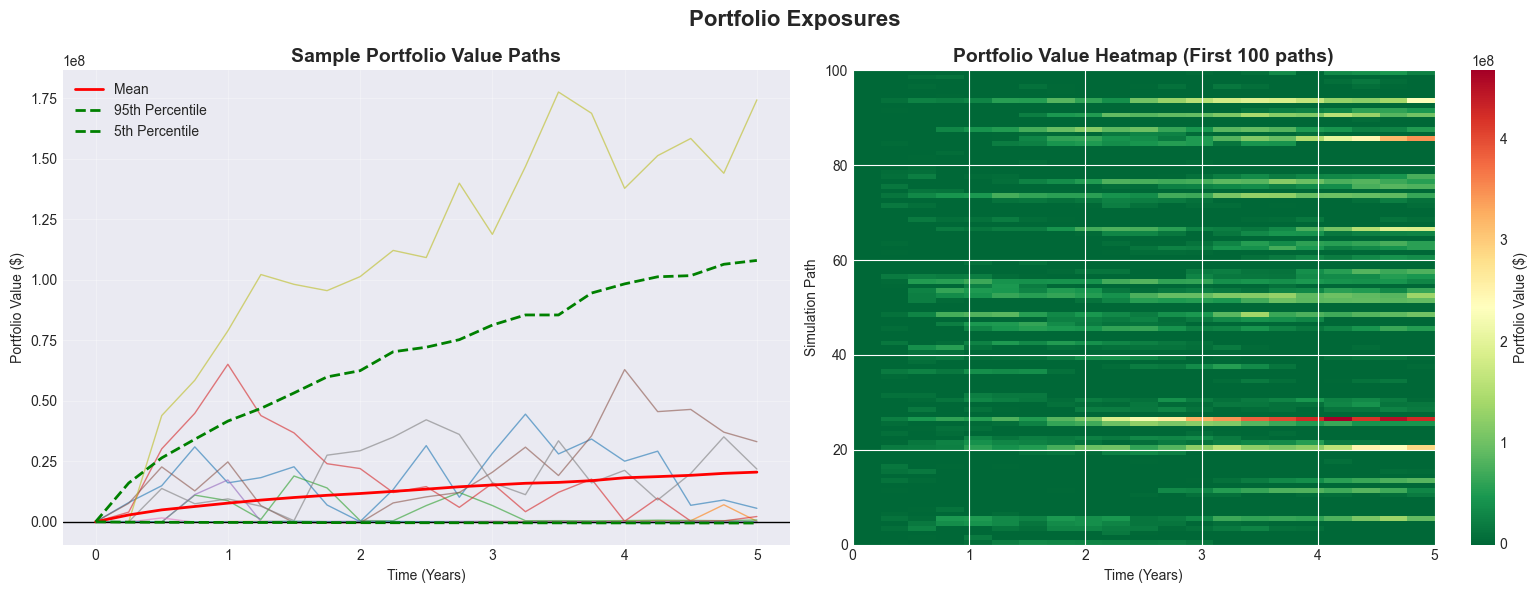

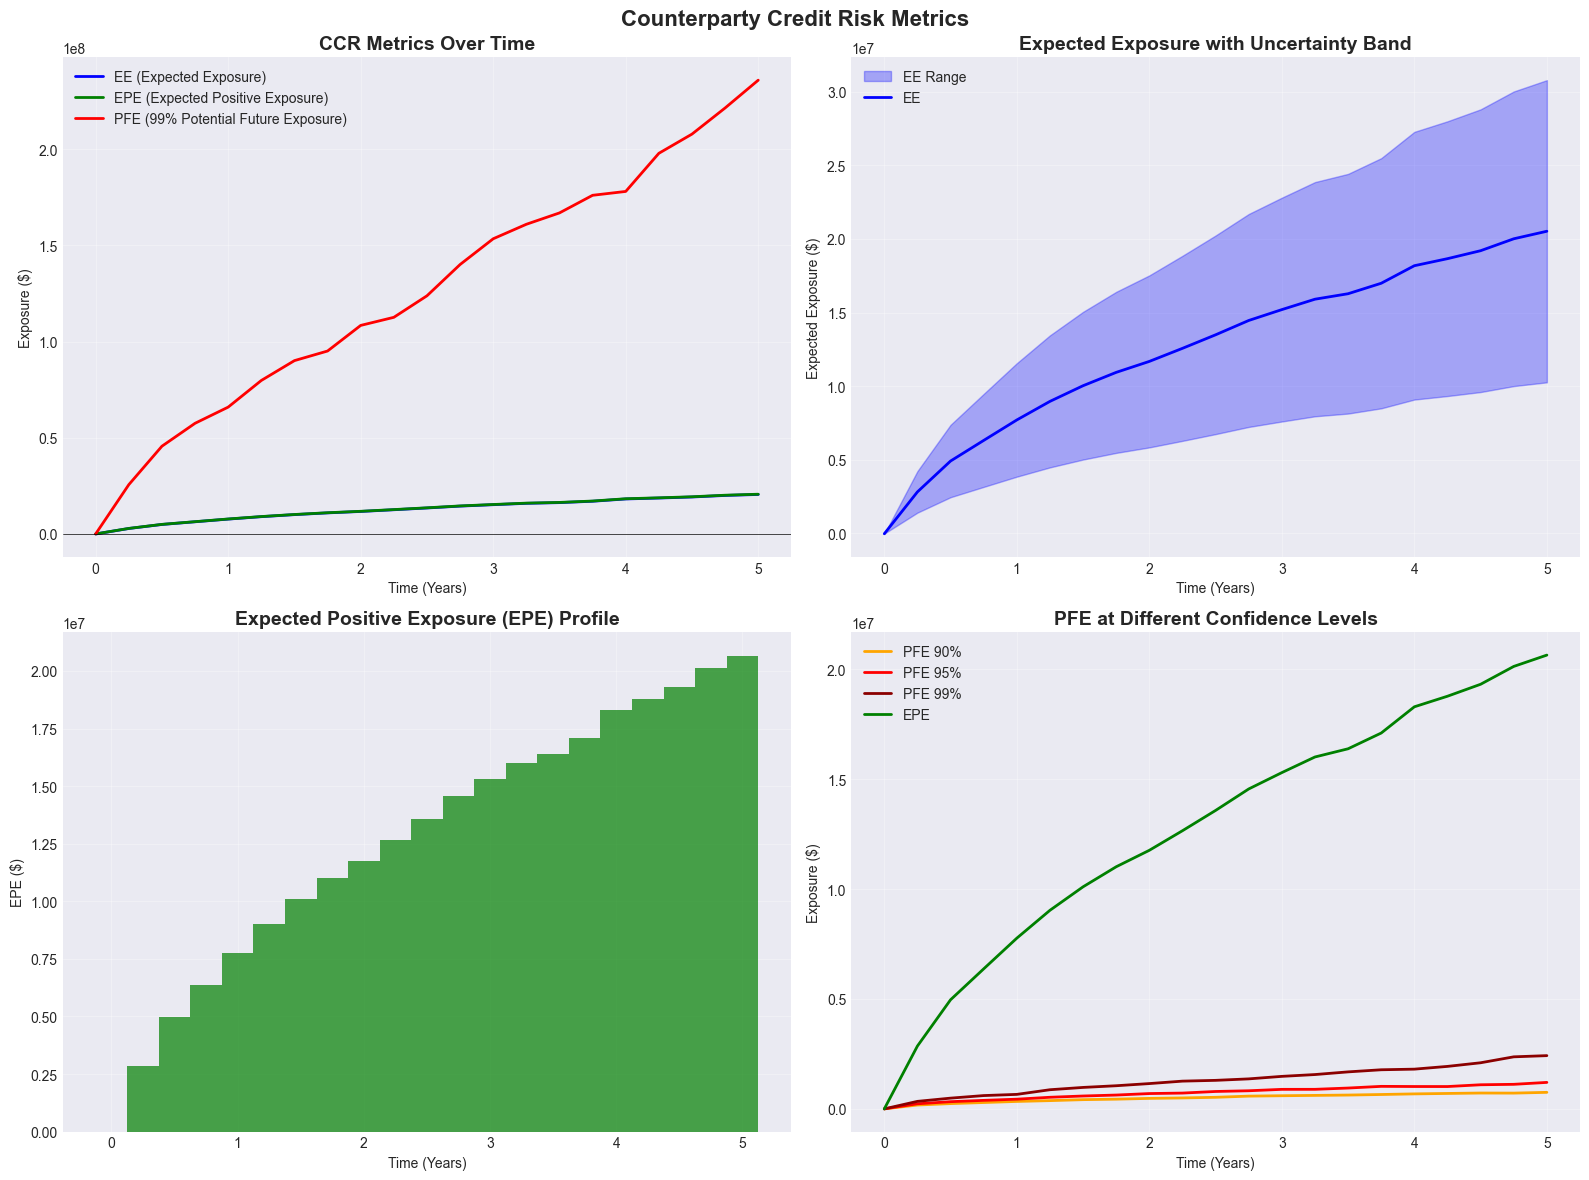

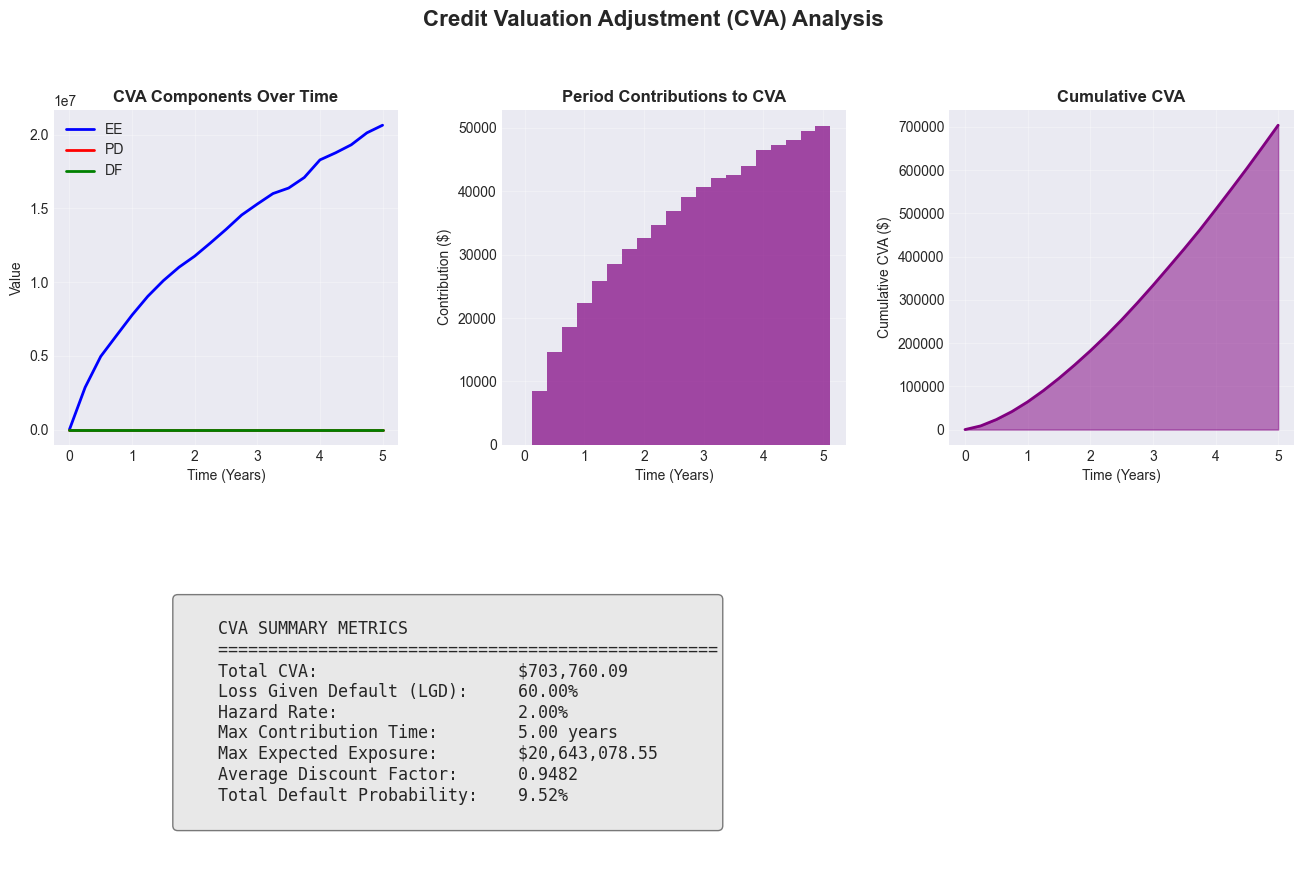

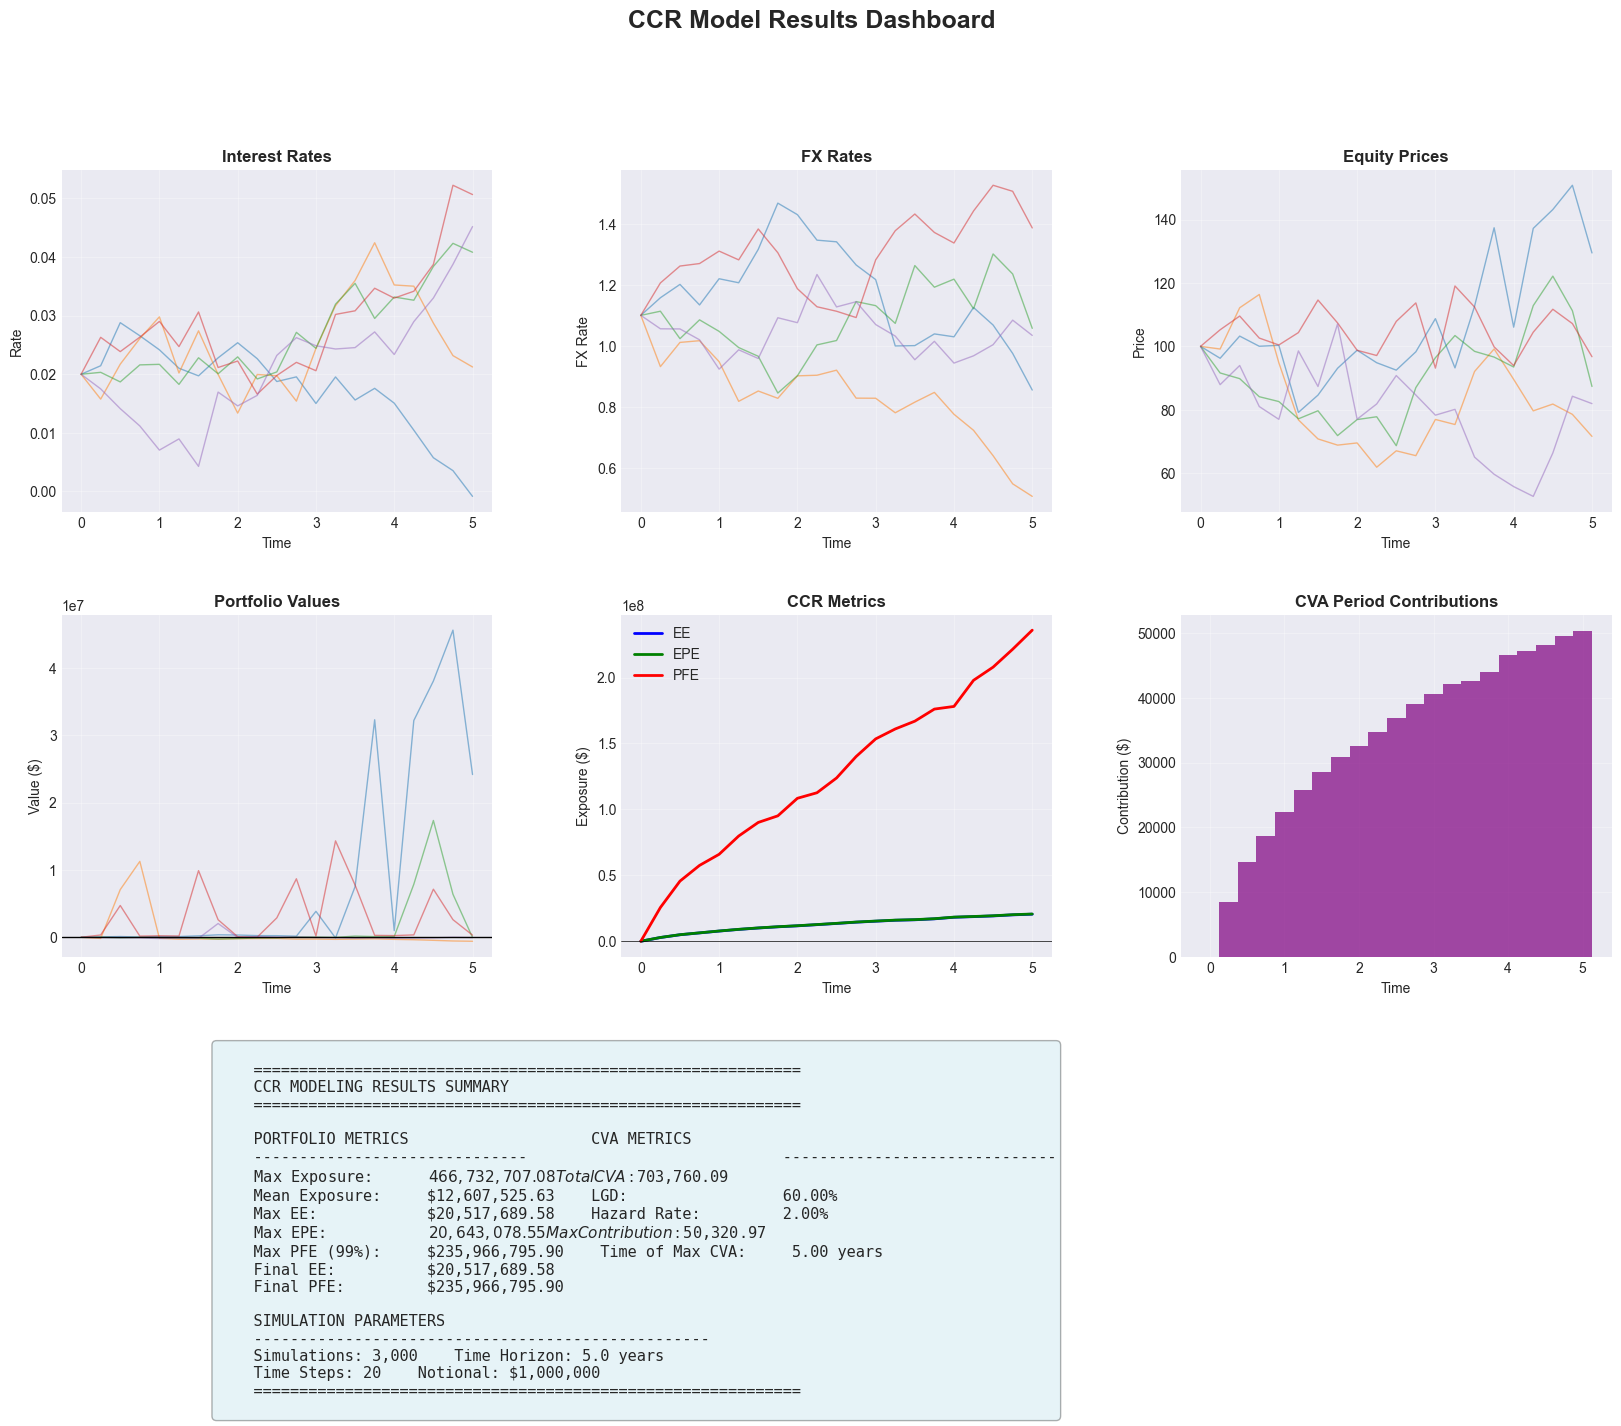

All plots generated successfully!

EXAMPLE 2: CVA SENSITIVITY TO HAZARD RATE
Hazard rate: 1.00% -> CVA: $167,459.73
Hazard rate: 2.00% -> CVA: $328,932.73
Hazard rate: 3.00% -> CVA: $484,609.20
Hazard rate: 5.00% -> CVA: $779,304.47
Hazard rate: 10.00% -> CVA: $1,426,838.63


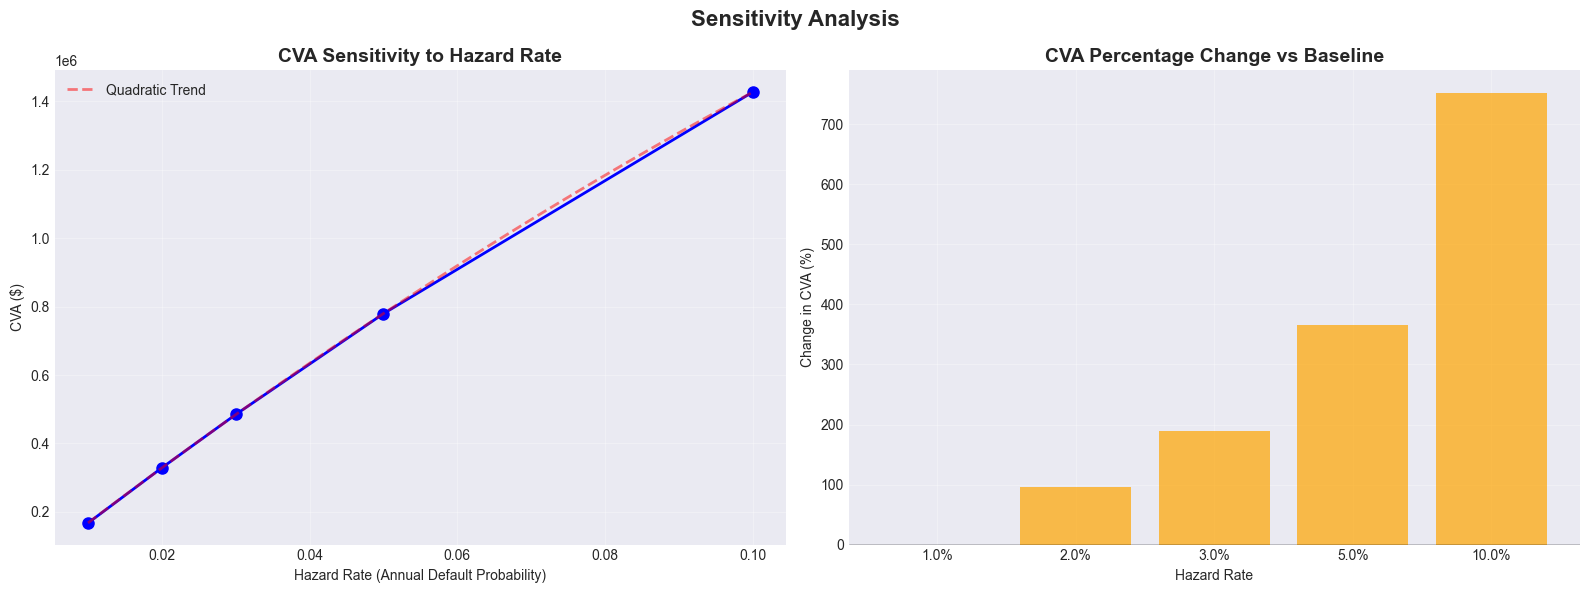


EXAMPLE 3: MANUAL STEP-BY-STEP EXECUTION WITH PLOTS
Step 1: Simulating markets...
Step 2: Valuing portfolio...
Step 3: Calculating CCR metrics...
  Max EE: 232910.76
  Max PFE: 2422750.83
Step 4: Calculating CVA...
  CVA: $8,286.12

Step 5: Generating plots...


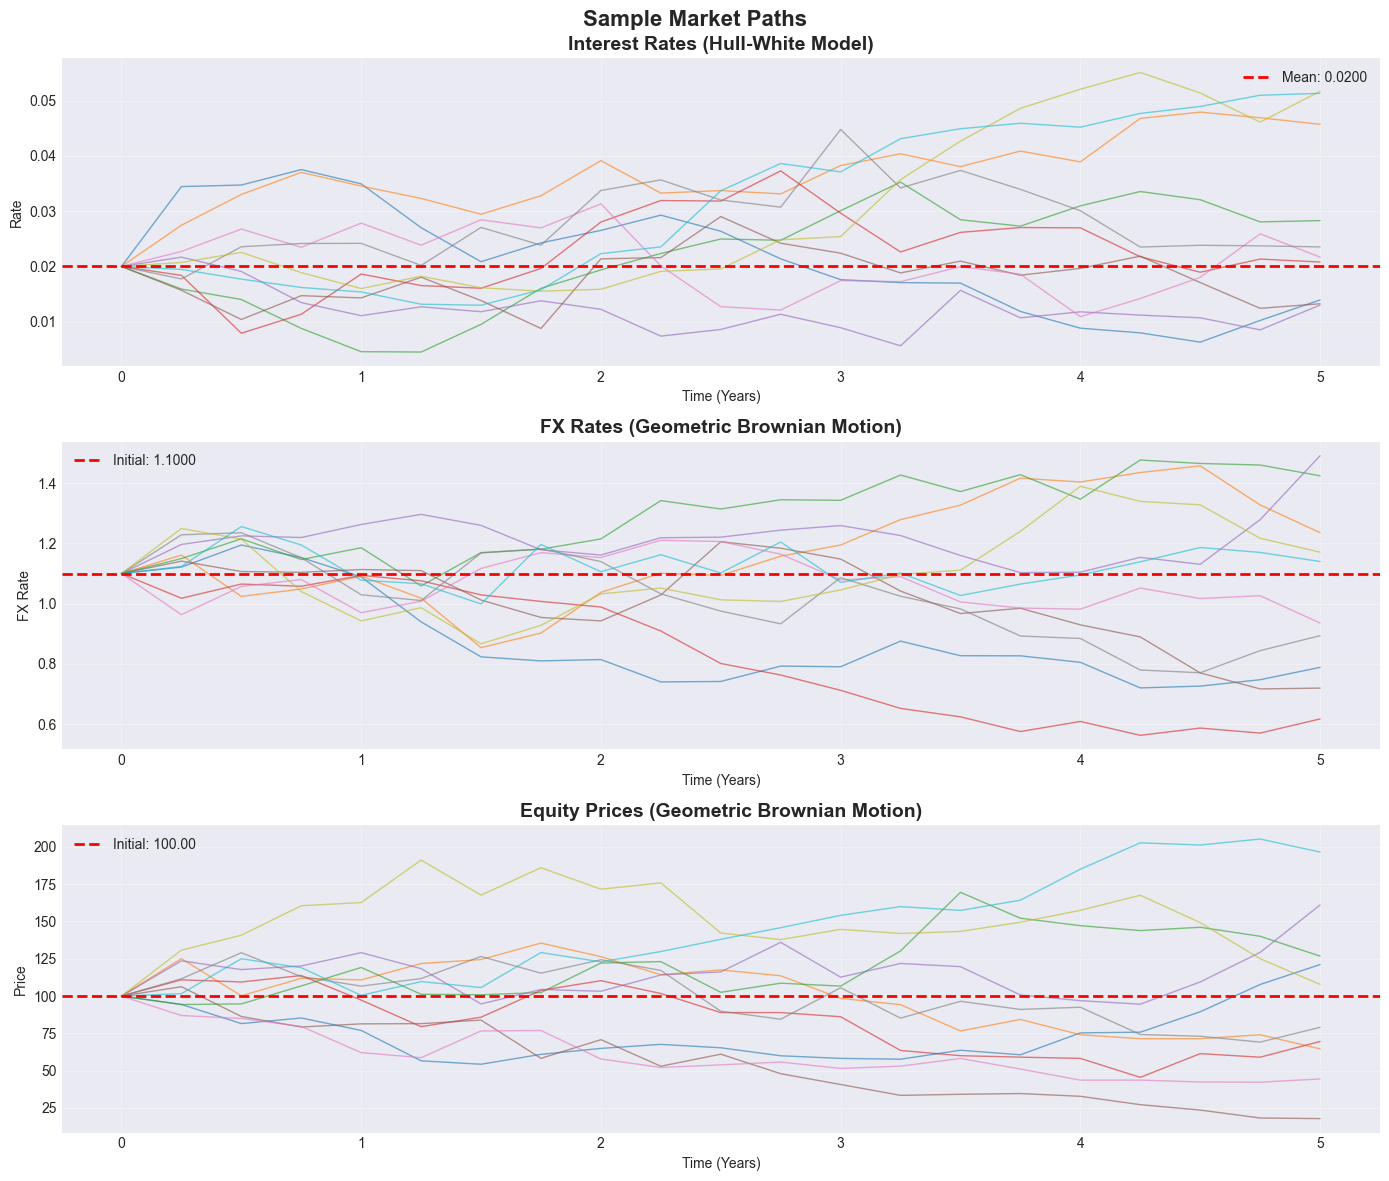

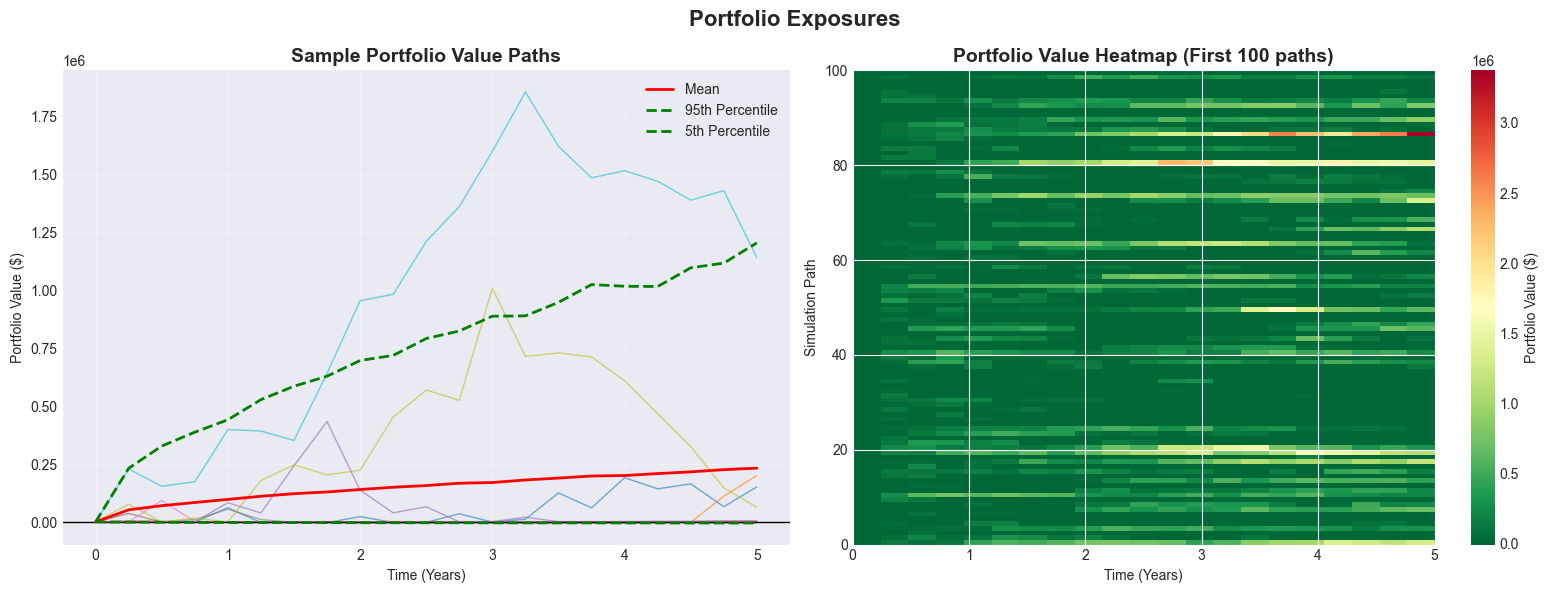

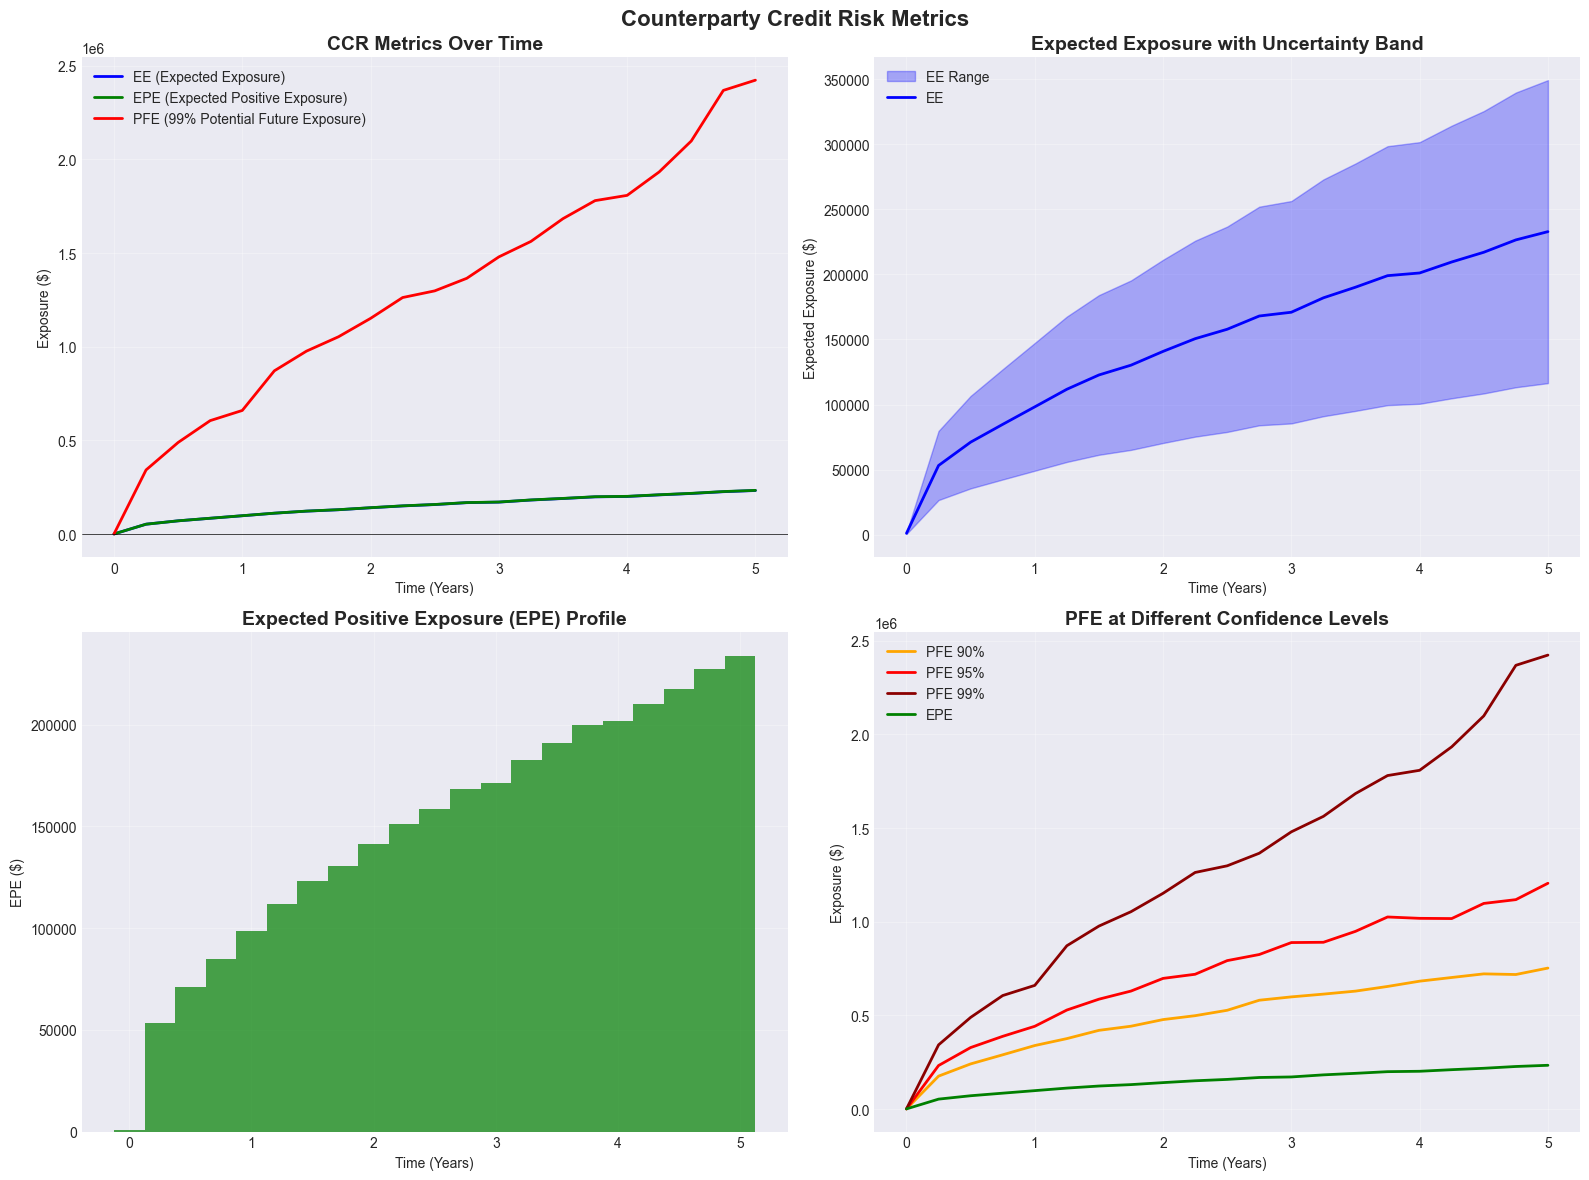

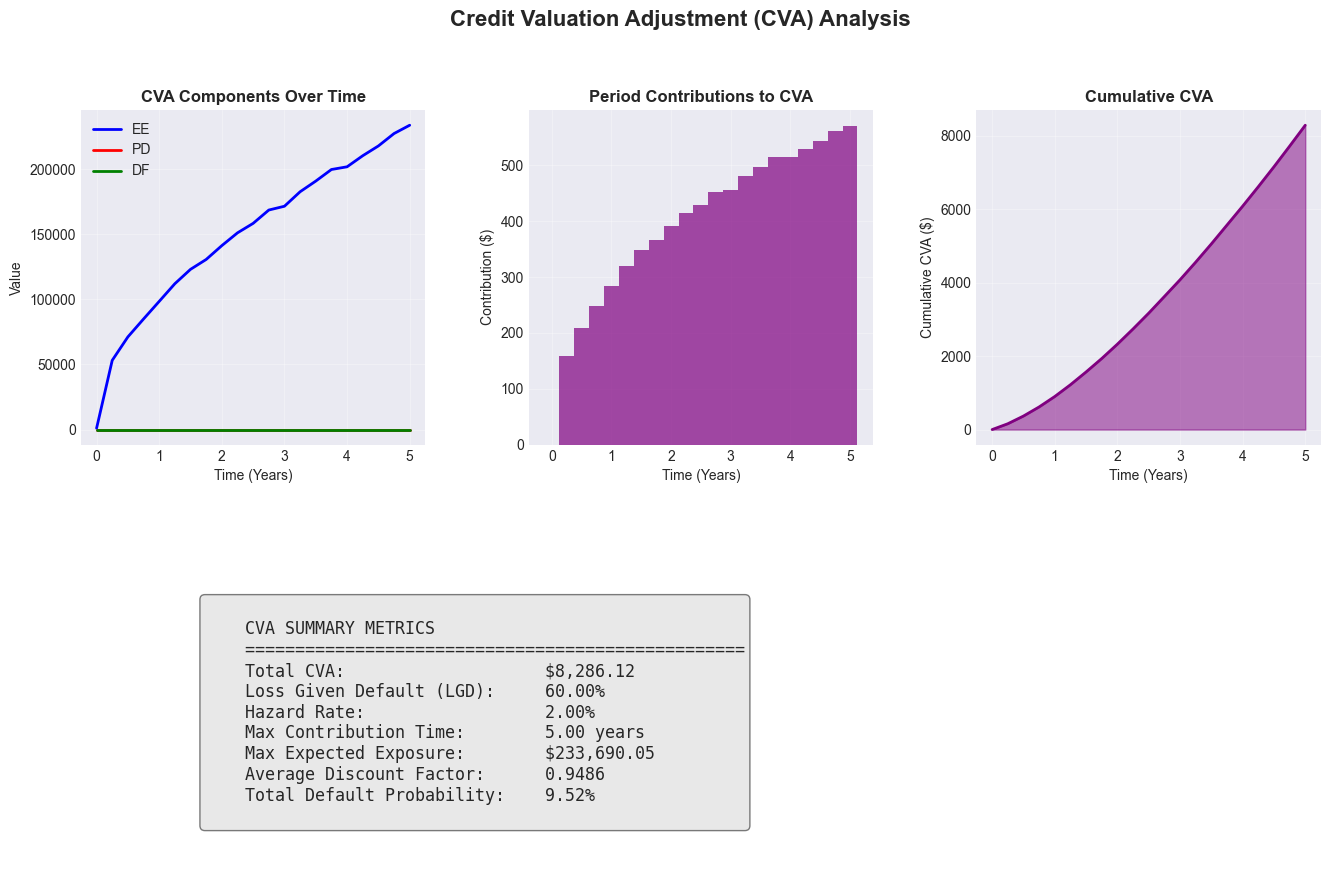

In [29]:
"""
Multi-Asset Modeling with CVA
Complete functional implementation with visualization
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['lines.linewidth'] = 2

# Step 1: Generate correlated normals
def generate_correlated_normals(num_simulations, cor_matrix, seed=1000):
    """
    Generate correlated normal random variables using Cholesky decomposition.
    """
    rng = np.random.default_rng(seed=seed)
    L = np.linalg.cholesky(cor_matrix)
    z = rng.normal(size=(num_simulations, cor_matrix.shape[0]))
    return z @ L.T


# Step 2: Simulate markets
def simulate_markets(r0, s0_fx, s0_eq, kappa, theta, sigma_r, sigma_fx, sigma_eq, 
                     cor_matrix, T, dt, num_simulations, seed=11000):
    """
    Simulate correlated markets: rates (Hull-White), FX (GBM), Equity (GBM).
    """
    n_steps = int(T/dt) + 1

    rates = np.zeros((num_simulations, n_steps))
    fx = np.zeros((num_simulations, n_steps))
    equity = np.zeros((num_simulations, n_steps))

    rates[:, 0] = r0
    fx[:, 0] = s0_fx
    equity[:, 0] = s0_eq

    # Hull-White parameters
    exp_kdt = np.exp(-kappa * dt)
    vol_r = sigma_r * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa))

    for t in range(1, n_steps):
        shocks = generate_correlated_normals(num_simulations=num_simulations, 
                                            cor_matrix=cor_matrix, 
                                            seed=seed + t)

        z_r = shocks[:, 0]
        z_fx = shocks[:, 1]
        z_eq = shocks[:, 2]

        rates[:, t] = (rates[:, t-1] * exp_kdt + theta * (1 - exp_kdt) + vol_r * z_r)
        fx[:, t] = fx[:, t-1] * np.exp(-0.5 * sigma_fx**2 * dt + sigma_fx * np.sqrt(dt) * z_fx)
        equity[:, t] = equity[:, t-1] * np.exp(-0.5 * sigma_eq**2 * dt + sigma_eq * np.sqrt(dt) * z_eq)

    return rates, fx, equity


# Step 3: Portfolio valuation
def portfolio_valuation(rates, fx, equity, swap_rate=0.02, fx_strike=1.00, 
                        eq_strike=100, notional=10_000):
    """
    Value the portfolio consisting of IRS swap, FX forward, and equity call option.
    """
    swap = notional * (rates - swap_rate)
    fx_trade = notional * (fx - fx_strike)
    eq_trade = notional * np.maximum(equity - eq_strike, 0)

    portfolio_value = swap + fx_trade + eq_trade
    return portfolio_value


# Step 4: CCR metrics
def ccr_metrics(exp, q=0.99):
    """
    Calculate CCR metrics: EE, EPE, PFE.
    """
    ee = np.mean(exp, axis=0)
    epe = np.mean(np.maximum(exp, 0), axis=0)
    pfe = np.quantile(np.maximum(exp, 0), q, axis=0)
    return ee, epe, pfe


# Step 5: CVA Calculation
def calculate_cva(portfolio_values, rates, time_grid, hazard_rate, recovery_rate=0.4, dt=None):
    """
    Calculate Credit Valuation Adjustment (CVA).
    """
    lgd = 1 - recovery_rate
    
    ee = np.mean(np.maximum(portfolio_values, 0), axis=0)
    
    survival_prob = np.exp(-hazard_rate * time_grid)
    default_prob = np.zeros_like(survival_prob)
    default_prob[0] = 1 - survival_prob[0]
    for i in range(1, len(survival_prob)):
        default_prob[i] = survival_prob[i-1] - survival_prob[i]
    
    n_sim, n_steps = rates.shape
    pathwise_df = np.zeros_like(rates)
    pathwise_df[:, 0] = 1.0
    
    for t in range(1, n_steps):
        if dt is not None:
            dt_t = dt
        else:
            dt_t = time_grid[t] - time_grid[t-1]
        pathwise_df[:, t] = pathwise_df[:, t-1] * np.exp(-rates[:, t] * dt_t)
    
    avg_discount_factors = np.mean(pathwise_df, axis=0)
    cva = lgd * np.sum(ee * default_prob * avg_discount_factors)
    
    period_contributions = lgd * ee * default_prob * avg_discount_factors
    max_contribution_idx = np.argmax(period_contributions)
    max_contribution_time = time_grid[max_contribution_idx]
    
    return {
        'cva': cva,
        'expected_exposure': ee,
        'default_probabilities': default_prob,
        'discount_factors': avg_discount_factors,
        'period_contributions': period_contributions,
        'max_contribution_time': max_contribution_time,
        'lgd': lgd,
        'hazard_rate': hazard_rate
    }


# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_market_paths(rates, fx, equity, time_grid, num_paths=10, save_path=None):
    """
    Plot sample paths for rates, FX, and equity.
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # Select random paths to plot
    if rates.shape[0] > num_paths:
        idx = np.random.choice(rates.shape[0], num_paths, replace=False)
    else:
        idx = range(rates.shape[0])
    
    # Plot rates
    for i in idx:
        axes[0].plot(time_grid, rates[i, :], alpha=0.6, linewidth=1)
    axes[0].axhline(y=np.mean(rates, axis=0)[0], color='red', linestyle='--', 
                    label=f'Mean: {np.mean(rates[:, 0]):.4f}')
    axes[0].set_title('Interest Rates (Hull-White Model)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Time (Years)')
    axes[0].set_ylabel('Rate')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot FX
    for i in idx:
        axes[1].plot(time_grid, fx[i, :], alpha=0.6, linewidth=1)
    axes[1].axhline(y=np.mean(fx[:, 0]), color='red', linestyle='--',
                    label=f'Initial: {np.mean(fx[:, 0]):.4f}')
    axes[1].set_title('FX Rates (Geometric Brownian Motion)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Time (Years)')
    axes[1].set_ylabel('FX Rate')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot Equity
    for i in idx:
        axes[2].plot(time_grid, equity[i, :], alpha=0.6, linewidth=1)
    axes[2].axhline(y=np.mean(equity[:, 0]), color='red', linestyle='--',
                    label=f'Initial: {np.mean(equity[:, 0]):.2f}')
    axes[2].set_title('Equity Prices (Geometric Brownian Motion)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Time (Years)')
    axes[2].set_ylabel('Price')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('Sample Market Paths', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f'{save_path}_market_paths.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_portfolio_exposures(portfolio_values, time_grid, num_paths=10, save_path=None):
    """
    Plot sample portfolio value paths.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Select random paths
    if portfolio_values.shape[0] > num_paths:
        idx = np.random.choice(portfolio_values.shape[0], num_paths, replace=False)
    else:
        idx = range(portfolio_values.shape[0])
    
    # Plot portfolio paths
    for i in idx:
        ax1.plot(time_grid, portfolio_values[i, :], alpha=0.6, linewidth=1)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax1.set_title('Sample Portfolio Value Paths', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Time (Years)')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.grid(True, alpha=0.3)
    
    # Add mean and quantiles
    mean_portfolio = np.mean(portfolio_values, axis=0)
    p95_portfolio = np.quantile(portfolio_values, 0.95, axis=0)
    p05_portfolio = np.quantile(portfolio_values, 0.05, axis=0)
    
    ax1.plot(time_grid, mean_portfolio, 'r-', linewidth=2, label='Mean')
    ax1.plot(time_grid, p95_portfolio, 'g--', linewidth=2, label='95th Percentile')
    ax1.plot(time_grid, p05_portfolio, 'g--', linewidth=2, label='5th Percentile')
    ax1.legend()
    
    # Heatmap of portfolio values
    im = ax2.imshow(portfolio_values[:min(100, portfolio_values.shape[0]), :], 
                    aspect='auto', cmap='RdYlGn_r', 
                    extent=[time_grid[0], time_grid[-1], 0, min(100, portfolio_values.shape[0])])
    ax2.set_title('Portfolio Value Heatmap (First 100 paths)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Time (Years)')
    ax2.set_ylabel('Simulation Path')
    plt.colorbar(im, ax=ax2, label='Portfolio Value ($)')
    
    plt.suptitle('Portfolio Exposures', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f'{save_path}_portfolio_exposures.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_ccr_metrics(ee, epe, pfe, time_grid, save_path=None):
    """
    Plot CCR metrics: EE, EPE, PFE.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot EE, EPE, PFE
    axes[0, 0].plot(time_grid, ee, 'b-', linewidth=2, label='EE (Expected Exposure)')
    axes[0, 0].plot(time_grid, epe, 'g-', linewidth=2, label='EPE (Expected Positive Exposure)')
    axes[0, 0].plot(time_grid, pfe, 'r-', linewidth=2, label='PFE (99% Potential Future Exposure)')
    axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[0, 0].set_title('CCR Metrics Over Time', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Time (Years)')
    axes[0, 0].set_ylabel('Exposure ($)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot EE with confidence bands
    positive_exposures = np.maximum(epe.reshape(1, -1), 0)
    lower = np.quantile(positive_exposures, 0.25, axis=0) if len(positive_exposures.shape) > 1 else positive_exposures * 0.5
    upper = np.quantile(positive_exposures, 0.75, axis=0) if len(positive_exposures.shape) > 1 else positive_exposures * 1.5
    
    axes[0, 1].fill_between(time_grid, ee * 0.5, ee * 1.5, alpha=0.3, color='blue', label='EE Range')
    axes[0, 1].plot(time_grid, ee, 'b-', linewidth=2, label='EE')
    axes[0, 1].set_title('Expected Exposure with Uncertainty Band', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Time (Years)')
    axes[0, 1].set_ylabel('Expected Exposure ($)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot EPE profile
    axes[1, 0].bar(time_grid, epe, width=time_grid[1]-time_grid[0], alpha=0.7, color='green')
    axes[1, 0].set_title('Expected Positive Exposure (EPE) Profile', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Time (Years)')
    axes[1, 0].set_ylabel('EPE ($)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot PFE percentiles
    percentiles = [0.90, 0.95, 0.99]
    colors = ['orange', 'red', 'darkred']
    for p, c in zip(percentiles, colors):
        pfe_p = np.quantile(np.maximum(portfolio_values, 0), p, axis=0)
        axes[1, 1].plot(time_grid, pfe_p, '-', color=c, linewidth=2, label=f'PFE {p*100:.0f}%')
    axes[1, 1].plot(time_grid, epe, 'g-', linewidth=2, label='EPE')
    axes[1, 1].set_title('PFE at Different Confidence Levels', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Time (Years)')
    axes[1, 1].set_ylabel('Exposure ($)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Counterparty Credit Risk Metrics', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f'{save_path}_ccr_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_cva_breakdown(cva_results, time_grid, save_path=None):
    """
    Plot CVA breakdown components.
    """
    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    # 1. CVA components over time
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(time_grid, cva_results['expected_exposure'], 'b-', linewidth=2, label='EE')
    ax1.plot(time_grid, cva_results['default_probabilities'], 'r-', linewidth=2, label='PD')
    ax1.plot(time_grid, cva_results['discount_factors'], 'g-', linewidth=2, label='DF')
    ax1.set_title('CVA Components Over Time', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Time (Years)')
    ax1.set_ylabel('Value')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Period contributions to CVA
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(time_grid, cva_results['period_contributions'], width=time_grid[1]-time_grid[0], 
            alpha=0.7, color='purple')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_title('Period Contributions to CVA', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Time (Years)')
    ax2.set_ylabel('Contribution ($)')
    ax2.grid(True, alpha=0.3)
    
    # 3. Cumulative CVA
    ax3 = fig.add_subplot(gs[0, 2])
    cumulative_cva = np.cumsum(cva_results['period_contributions'])
    ax3.fill_between(time_grid, 0, cumulative_cva, alpha=0.5, color='purple')
    ax3.plot(time_grid, cumulative_cva, 'purple', linewidth=2)
    ax3.set_title('Cumulative CVA', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Time (Years)')
    ax3.set_ylabel('Cumulative CVA ($)')
    ax3.grid(True, alpha=0.3)
    
    # 4. Summary metrics
    ax4 = fig.add_subplot(gs[1, :])
    ax4.axis('off')
    
    summary_text = f"""
    CVA SUMMARY METRICS
    {'='*50}
    Total CVA:                    ${cva_results['cva']:,.2f}
    Loss Given Default (LGD):     {cva_results['lgd']:.2%}
    Hazard Rate:                  {cva_results['hazard_rate']:.2%}
    Max Contribution Time:        {cva_results['max_contribution_time']:.2f} years
    Max Expected Exposure:        ${np.max(cva_results['expected_exposure']):,.2f}
    Average Discount Factor:      {np.mean(cva_results['discount_factors']):.4f}
    Total Default Probability:    {1 - np.exp(-cva_results['hazard_rate'] * time_grid[-1]):.2%}
    """
    
    ax4.text(0.1, 0.5, summary_text, transform=ax4.transAxes, fontsize=12,
             verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
    
    plt.suptitle('Credit Valuation Adjustment (CVA) Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f'{save_path}_cva_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_sensitivity_analysis(hazard_rates, cva_values, save_path=None):
    """
    Plot sensitivity of CVA to hazard rate.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot CVA vs hazard rate
    ax1.plot(hazard_rates, cva_values, 'bo-', linewidth=2, markersize=8)
    ax1.set_title('CVA Sensitivity to Hazard Rate', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Hazard Rate (Annual Default Probability)')
    ax1.set_ylabel('CVA ($)')
    ax1.grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(hazard_rates, cva_values, 2)
    p = np.poly1d(z)
    x_trend = np.linspace(min(hazard_rates), max(hazard_rates), 100)
    ax1.plot(x_trend, p(x_trend), 'r--', alpha=0.5, label='Quadratic Trend')
    ax1.legend()
    
    # Plot CVA vs hazard rate with percentage change
    cva_percent_change = [(cva / cva_values[0] - 1) * 100 for cva in cva_values]
    ax2.bar([f'{hr:.1%}' for hr in hazard_rates], cva_percent_change, alpha=0.7, color='orange')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax2.set_title('CVA Percentage Change vs Baseline', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Hazard Rate')
    ax2.set_ylabel('Change in CVA (%)')
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Sensitivity Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f'{save_path}_sensitivity.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_all_results(results, save_path=None):
    """
    Plot all results in a comprehensive dashboard.
    """
    # Extract data
    rates = results['rates']
    fx = results['fx']
    equity = results['equity']
    portfolio_values = results['portfolio_values']
    ee = results['ee']
    epe = results['epe']
    pfe = results['pfe']
    cva_results = results['cva_results']
    time_grid = results['time_grid']
    
    # Create comprehensive dashboard
    fig = plt.figure(figsize=(20, 16))
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    # 1. Market paths (top row)
    ax1 = fig.add_subplot(gs[0, 0])
    for i in range(min(5, rates.shape[0])):
        ax1.plot(time_grid, rates[i, :], alpha=0.5, linewidth=1)
    ax1.set_title('Interest Rates', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Rate')
    ax1.grid(True, alpha=0.3)
    
    ax2 = fig.add_subplot(gs[0, 1])
    for i in range(min(5, fx.shape[0])):
        ax2.plot(time_grid, fx[i, :], alpha=0.5, linewidth=1)
    ax2.set_title('FX Rates', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('FX Rate')
    ax2.grid(True, alpha=0.3)
    
    ax3 = fig.add_subplot(gs[0, 2])
    for i in range(min(5, equity.shape[0])):
        ax3.plot(time_grid, equity[i, :], alpha=0.5, linewidth=1)
    ax3.set_title('Equity Prices', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Price')
    ax3.grid(True, alpha=0.3)
    
    # 2. Portfolio exposures (middle row)
    ax4 = fig.add_subplot(gs[1, 0])
    for i in range(min(5, portfolio_values.shape[0])):
        ax4.plot(time_grid, portfolio_values[i, :], alpha=0.5, linewidth=1)
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax4.set_title('Portfolio Values', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Time')
    ax4.set_ylabel('Value ($)')
    ax4.grid(True, alpha=0.3)
    
    # 3. CCR metrics (middle center)
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(time_grid, ee, 'b-', linewidth=2, label='EE')
    ax5.plot(time_grid, epe, 'g-', linewidth=2, label='EPE')
    ax5.plot(time_grid, pfe, 'r-', linewidth=2, label='PFE')
    ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax5.set_title('CCR Metrics', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Time')
    ax5.set_ylabel('Exposure ($)')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 4. CVA components (middle right)
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.bar(time_grid, cva_results['period_contributions'], 
            width=time_grid[1]-time_grid[0], alpha=0.7, color='purple')
    ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax6.set_title('CVA Period Contributions', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Time')
    ax6.set_ylabel('Contribution ($)')
    ax6.grid(True, alpha=0.3)
    
    # 5. Summary (bottom row, spanning all)
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('off')
    
    summary_text = f"""
    {'='*60}
    CCR MODELING RESULTS SUMMARY
    {'='*60}
    
    PORTFOLIO METRICS                    CVA METRICS
    {'-'*30}                            {'-'*30}
    Max Exposure:      ${np.max(portfolio_values):,.2f}    Total CVA:           ${cva_results['cva']:,.2f}
    Mean Exposure:     ${np.mean(portfolio_values):,.2f}    LGD:                 {cva_results['lgd']:.2%}
    Max EE:            ${np.max(ee):,.2f}    Hazard Rate:         {cva_results['hazard_rate']:.2%}
    Max EPE:           ${np.max(epe):,.2f}    Max Contribution:    ${np.max(cva_results['period_contributions']):,.2f}
    Max PFE (99%):     ${np.max(pfe):,.2f}    Time of Max CVA:     {cva_results['max_contribution_time']:.2f} years
    Final EE:          ${ee[-1]:,.2f}
    Final PFE:         ${pfe[-1]:,.2f}
    
    SIMULATION PARAMETERS
    {'-'*50}
    Simulations: {results['parameters']['num_simulations']:,}    Time Horizon: {results['parameters']['T']:.1f} years
    Time Steps: {len(time_grid)-1}    Notional: ${results['parameters']['notional']:,.0f}
    {'='*60}
    """
    
    ax7.text(0.1, 0.5, summary_text, transform=ax7.transAxes, fontsize=11,
             verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    
    plt.suptitle('CCR Model Results Dashboard', fontsize=18, fontweight='bold')
    
    if save_path:
        plt.savefig(f'{save_path}_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()


# Step 6: Complete workflow with CVA integration and visualization
def run_complete_ccr_model(
    # Market parameters
    r0=0.02, s0_fx=1.10, s0_eq=100.0,
    kappa=0.1, theta=0.03, sigma_r=0.01,
    sigma_fx=0.15, sigma_eq=0.25,
    cor_matrix=None,
    
    # Simulation parameters
    T=5.0, dt=0.25, num_simulations=10000, seed=42,
    
    # Trade parameters
    swap_rate=0.025, fx_strike=1.12, eq_strike=105.0,
    notional=1_000_000,
    
    # CVA parameters
    hazard_rate=0.02, recovery_rate=0.4,
    
    # Output options
    verbose=True,
    plot_results=True,
    save_plots=False,
    plot_path="results"
):
    """
    Run complete CCR model including simulation, valuation, metrics, and CVA with visualization.
    """
    
    import os
    if save_plots and not os.path.exists(plot_path):
        os.makedirs(plot_path)
    
    # Set default correlation matrix if not provided
    if cor_matrix is None:
        cor_matrix = np.array([
            [1.0, 0.3, 0.2],
            [0.3, 1.0, 0.4],
            [0.2, 0.4, 1.0]
        ])
    
    if verbose:
        print("=" * 70)
        print("RUNNING COMPLETE CCR MODEL WITH CVA")
        print("=" * 70)
        print(f"Simulations: {num_simulations:,}")
        print(f"Time horizon: {T} years")
        print(f"Time steps: {int(T/dt)}")
        print(f"Notional: ${notional:,.0f}")
        print(f"Hazard rate: {hazard_rate:.2%}")
        print(f"Recovery rate: {recovery_rate:.2%}")
        print("-" * 70)
    
    # Step 1: Simulate markets
    if verbose:
        print("Step 1: Simulating markets...")
    
    rates, fx, equity = simulate_markets(
        r0=r0, s0_fx=s0_fx, s0_eq=s0_eq,
        kappa=kappa, theta=theta,
        sigma_r=sigma_r, sigma_fx=sigma_fx, sigma_eq=sigma_eq,
        cor_matrix=cor_matrix,
        T=T, dt=dt,
        num_simulations=num_simulations,
        seed=seed
    )
    
    if verbose:
        print(f"  Rates shape: {rates.shape}")
        print(f"  FX shape: {fx.shape}")
        print(f"  Equity shape: {equity.shape}")
    
    # Step 2: Value portfolio
    if verbose:
        print("Step 2: Valuing portfolio...")
    
    portfolio_values = portfolio_valuation(
        rates=rates, fx=fx, equity=equity,
        swap_rate=swap_rate, fx_strike=fx_strike,
        eq_strike=eq_strike, notional=notional
    )
    
    if verbose:
        print(f"  Portfolio value range: [{np.min(portfolio_values):.2f}, {np.max(portfolio_values):.2f}]")
        print(f"  Mean portfolio value: {np.mean(portfolio_values):.2f}")
    
    # Step 3: Calculate CCR metrics
    if verbose:
        print("Step 3: Calculating CCR metrics...")
    
    ee, epe, pfe = ccr_metrics(portfolio_values, q=0.99)
    
    if verbose:
        print(f"  Max EE: {np.max(ee):.2f}")
        print(f"  Max EPE: {np.max(epe):.2f}")
        print(f"  Max PFE (99%): {np.max(pfe):.2f}")
        print(f"  Final EE: {ee[-1]:.2f}")
    
    # Step 4: Calculate CVA
    if verbose:
        print("Step 4: Calculating CVA...")
    
    n_steps = int(T/dt) + 1
    time_grid = np.linspace(0, T, n_steps)
    
    cva_results = calculate_cva(
        portfolio_values=portfolio_values,
        rates=rates,
        time_grid=time_grid,
        hazard_rate=hazard_rate,
        recovery_rate=recovery_rate,
        dt=dt
    )
    
    if verbose:
        print(f"  CVA: ${cva_results['cva']:,.2f}")
        print(f"  Max contribution at t={cva_results['max_contribution_time']:.2f} years")
        print(f"  LGD: {cva_results['lgd']:.2%}")
        print("-" * 70)
        print("SUMMARY RESULTS:")
        print(f"  Expected Exposure (final): ${ee[-1]:,.2f}")
        print(f"  Expected Positive Exposure (final): ${epe[-1]:,.2f}")
        print(f"  Potential Future Exposure (99%): ${pfe[-1]:,.2f}")
        print(f"  CVA: ${cva_results['cva']:,.2f}")
        print("=" * 70)
    
    # Prepare results dictionary
    results = {
        'rates': rates,
        'fx': fx,
        'equity': equity,
        'portfolio_values': portfolio_values,
        'ee': ee,
        'epe': epe,
        'pfe': pfe,
        'cva_results': cva_results,
        'time_grid': time_grid,
        'parameters': {
            'r0': r0, 's0_fx': s0_fx, 's0_eq': s0_eq,
            'kappa': kappa, 'theta': theta,
            'sigma_r': sigma_r, 'sigma_fx': sigma_fx, 'sigma_eq': sigma_eq,
            'T': T, 'dt': dt,
            'num_simulations': num_simulations,
            'swap_rate': swap_rate,
            'fx_strike': fx_strike,
            'eq_strike': eq_strike,
            'notional': notional,
            'hazard_rate': hazard_rate,
            'recovery_rate': recovery_rate
        }
    }
    
    # Step 5: Plot results
    if plot_results:
        if verbose:
            print("\nGenerating plots...")
        
        save_path = plot_path if save_plots else None
        
        # Plot market paths
        plot_market_paths(rates, fx, equity, time_grid, num_paths=10, save_path=save_path)
        
        # Plot portfolio exposures
        plot_portfolio_exposures(portfolio_values, time_grid, num_paths=10, save_path=save_path)
        
        # Plot CCR metrics
        plot_ccr_metrics(ee, epe, pfe, time_grid, save_path=save_path)
        
        # Plot CVA breakdown
        plot_cva_breakdown(cva_results, time_grid, save_path=save_path)
        
        # Plot all results in dashboard
        plot_all_results(results, save_path=save_path)
        
        if verbose:
            print("All plots generated successfully!")
    
    return results


# =============================================================================
# Example Usage
# =============================================================================

if __name__ == "__main__":
    # Example 1: Run with default parameters and plots
    print("\n" + "=" * 70)
    print("EXAMPLE 1: STANDARD RUN WITH CVA AND PLOTS")
    print("=" * 70)
    
    results = run_complete_ccr_model(
        num_simulations=3000,  # Reduced for speed
        T=5.0,
        dt=0.25,
        verbose=True,
        plot_results=True,
        save_plots=False
    )
    
    # Example 2: Sensitivity analysis - varying hazard rate
    print("\n" + "=" * 70)
    print("EXAMPLE 2: CVA SENSITIVITY TO HAZARD RATE")
    print("=" * 70)
    
    hazard_rates = [0.01, 0.02, 0.03, 0.05, 0.10]
    cva_values = []
    
    for hr in hazard_rates:
        results_sens = run_complete_ccr_model(
            num_simulations=1000,  # Reduced for speed
            T=3.0,
            dt=0.25,
            hazard_rate=hr,
            verbose=False,
            plot_results=False
        )
        cva_values.append(results_sens['cva_results']['cva'])
        print(f"Hazard rate: {hr:.2%} -> CVA: ${results_sens['cva_results']['cva']:,.2f}")
    
    # Plot sensitivity analysis
    plot_sensitivity_analysis(hazard_rates, cva_values)
    
    # Example 3: Manual step-by-step with plots
    print("\n" + "=" * 70)
    print("EXAMPLE 3: MANUAL STEP-BY-STEP EXECUTION WITH PLOTS")
    print("=" * 70)
    
    # Parameters
    r0, s0_fx, s0_eq = 0.02, 1.10, 100.0
    kappa, theta, sigma_r = 0.1, 0.03, 0.01
    sigma_fx, sigma_eq = 0.15, 0.25
    cor_matrix = np.array([[1.0, 0.3, 0.2], [0.3, 1.0, 0.4], [0.2, 0.4, 1.0]])
    T, dt = 5.0, 0.25
    num_simulations = 2000
    
    # Step 1: Simulate
    print("Step 1: Simulating markets...")
    rates, fx, equity = simulate_markets(
        r0, s0_fx, s0_eq, kappa, theta, sigma_r, sigma_fx, sigma_eq,
        cor_matrix, T, dt, num_simulations, seed=123
    )
    
    # Step 2: Value portfolio
    print("Step 2: Valuing portfolio...")
    portfolio_values = portfolio_valuation(rates, fx, equity)
    
    # Step 3: Calculate CCR metrics
    print("Step 3: Calculating CCR metrics...")
    ee, epe, pfe = ccr_metrics(portfolio_values)
    print(f"  Max EE: {np.max(ee):.2f}")
    print(f"  Max PFE: {np.max(pfe):.2f}")
    
    # Step 4: Calculate CVA
    print("Step 4: Calculating CVA...")
    n_steps = int(T/dt) + 1
    time_grid = np.linspace(0, T, n_steps)
    cva_results = calculate_cva(
        portfolio_values, rates, time_grid,
        hazard_rate=0.02, recovery_rate=0.4, dt=dt
    )
    print(f"  CVA: ${cva_results['cva']:,.2f}")
    
    # Step 5: Plot results manually
    print("\nStep 5: Generating plots...")
    plot_market_paths(rates, fx, equity, time_grid, num_paths=10)
    plot_portfolio_exposures(portfolio_values, time_grid, num_paths=10)
    plot_ccr_metrics(ee, epe, pfe, time_grid)
    plot_cva_breakdown(cva_results, time_grid)
    